In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from scipy.spatial import distance

import os 
import sys
from format_waveform_data import get_spike_times
import waveform_analysis
sys.path.append("..//behavior/")
from format_behavior_data import load_behavior_data, get_caches_refined, get_visits_refined
sys.path.append("..//utils/")
import color_utils, helpers
from load_matlab_data import loadmat_sbx
from scipy.io import loadmat

In [2]:
''' File Paths '''
root_dir = "Z:/Isabel/data/hpc_implants/"
save_figs_dir = f"../figures/basic_neural_analysis/"
data_file = f"{root_dir}stim_session_data.npy"
session_info_file = f"{root_dir}good_sessions.xlsx"

# to load the arena objects
arena_dir = 'C:/Users/ilow1/Documents/code/il_rig_control/arena_alignment/'
arena_items_file = 'arena_items_2.mat'


''' Data params '''
bird = 'SLV132' # update as needed
data_dict = np.load(data_file, allow_pickle=True).item()
session_list = data_dict[bird]['all_sessions']
convert_norm_to_cm =  13 * 2.54

# collect sessions with pose tracking & ephys
behavior_sessions = []
for session_id in session_list:
    preprocessed_data = data_dict[bird][session_id]['preprocessed_data']
    if ('behavior' in preprocessed_data) & ('ephys' in preprocessed_data):
        behavior_sessions.append(session_id)

In [3]:
session_id = '250326'

In [4]:
print(f'collecting cache-aligned data for {bird}_{session_id}')

''' Get the file params '''
session_dir = f"{root_dir}{bird}/{bird}_{session_id}/"
data_dir = f"{session_dir}/behavior_data/"
pred_date = data_dict[bird][session_id]['pred_date']
ephys_id = data_dict[bird][session_id]['ephys_id']
ephys_folder= f"{root_dir}{bird}/{bird}_{session_id}/{bird}_{ephys_id}/"
for folder in sorted(os.listdir(ephys_folder)):
    if 'kilosort4' in folder:
        for file in sorted(os.listdir(f"{ephys_folder}{folder}")):
            if 'waveformStruct' in file:
                ks_dir = f"{bird}_{ephys_id}/{folder}/"

collecting cache-aligned data for SLV132_250326


In [5]:
''' Load the frame times '''
sampling_rate = 30000 # intan
framet_raw = np.load(f'{data_dir}frame_times.npy')
framet_raw = np.squeeze(framet_raw)
dt = np.unique(np.round(np.diff(framet_raw), 2))
dt = dt[0]

# align so that 0 is the video start time
start_t = framet_raw[0]
frame_t = framet_raw - start_t
frame_samples = np.append(frame_t, frame_t[-1] + dt)*sampling_rate
n_frames = frame_t.shape[0]

In [6]:
''' Load/format the neural data '''
# get the cell IDs and raw spike times
good_clusters, spike_id, spike_samp_raw = get_spike_times(session_dir, ks_dir=ks_dir)
n_cells = good_clusters.shape[0]

# keep only spikes from within the session
spike_t = spike_samp_raw - start_t*sampling_rate
spike_id = spike_id[(spike_t >= 0) & (spike_t <= frame_samples[-1])]
spike_t = spike_t[(spike_t >= 0) & (spike_t <= frame_samples[-1])]

# spikes per frame and spike bool
spike_frame = np.zeros((n_cells, n_frames))
i = -1
for c_idx, cell in enumerate(good_clusters):
    i += 1
    spk_times = spike_t[spike_id==cell]       
    spike_frame[i], _ = np.histogram(spk_times, frame_samples)
spike_bool = spike_frame.astype(bool)

# instantaneous firing rate
inst_firing_rate = spike_frame/dt

# session average firing rate
waveform_props = data_dict[bird][session_id]['waveform_props']
log_fr = waveform_props[2]
avg_firing_rate = 10**log_fr

In [35]:
''' Load and format behavior data '''
# load behavioral data
data_dir = f"{root_dir}{bird}/{bird}_{session_id}/behavior_data/"
seed_struct, count_data = load_behavior_data(data_dir)

# get the x, y coordinates of each perch center
arena_data = loadmat(f'{arena_dir}{arena_items_file}', squeeze_me=True)
n_sites = arena_data["perch_w_site"].shape[0]
perch_loc = np.zeros((n_sites, 2))
for site in range(n_sites):
    perch_loc[site] = arena_data["perch_w_site"][site]['Centroid']

# get cache interactions and visits
cache_onsets, cache_offsets, cache_ids = get_caches_refined(count_data, seed_struct, n_frames)
visit_onsets, visit_offsets, visit_ids = get_visits_refined(count_data, n_frames)

# exclude visits to feeder perches
visit_onsets = visit_onsets[visit_ids < n_sites]
visit_offsets = visit_offsets[visit_ids < n_sites]
visit_ids = visit_ids[visit_ids < n_sites]

n_caches = cache_onsets.shape[0]
n_visits = visit_onsets.shape[0]

Z:/Isabel/data/hpc_implants/SLV132/SLV132_250326/behavior_data/annotatedSeeds.mat


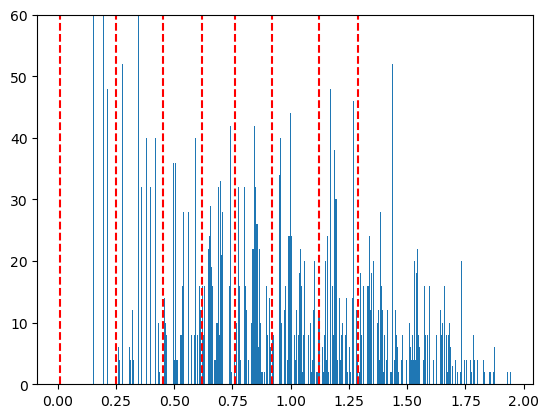

In [138]:
# get the distances between arena perches
perch_distances = distance.pdist(perch_loc)
perch_dist_bins = np.asarray([0, 0.01, 0.25, 0.45, 0.62, 0.76, 0.92, 1.12, 1.29, np.inf])
perch_dist_centers = (perch_dist_bins[:-1] + perch_dist_bins[1:]) / 2
perch_dist_centers[-1] = 1.4
perch_dist_centers_cm = perch_dist_centers*convert_norm_to_cm
n_bins = perch_dist_bins.shape[0]

plt.hist(perch_distances, bins=500)
plt.vlines(perch_dist_bins[1:-1], 0, 60, color='red', linestyles='dashed')
plt.ylim([0, 60])
plt.show()

In [36]:
# get the x, y coordinates of each cache/visit
cache_loc = np.zeros((n_caches, 2))
for cache_idx, cache_id in enumerate(cache_ids):
    cache_loc[cache_idx] = perch_loc[cache_id]
    
visit_loc = np.zeros((n_visits, 2))
for visit_idx, visit_id in enumerate(visit_ids):
    visit_loc[visit_idx] = perch_loc[visit_id]

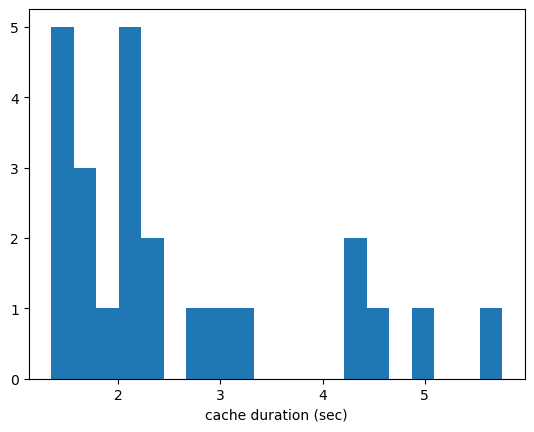

In [37]:
# plot cache durations
cache_dur = cache_offsets - cache_onsets
plt.hist(cache_dur/50, bins=20)
plt.xlabel('cache duration (sec)')
plt.show()

In [38]:
''' Average neural activity during each visit and cache '''
# account for long caches as in SC, EM 2024
long_thresh = 2 # seconds
long_window = int(long_thresh/2/dt) # frames

# get average activity during cache window
avg_cache = np.zeros((n_cells, n_caches))
for i, (cache_on, cache_off) in enumerate(zip(cache_onsets, cache_offsets)):
    if cache_off - cache_on < long_thresh:
        spike_count = np.sum(spike_frame[:, cache_on:cache_off], axis=1)
        occupancy = dt*(cache_off-cache_on)
        avg_cache[:, i] = spike_count/occupancy
    else:
        begin_count = np.sum(spike_frame[:, cache_on:cache_on+long_window], axis=1)
        end_count = np.sum(spike_frame[:, cache_off-long_window:cache_off], axis=1)
        spike_count = begin_count + end_count
        avg_cache[:, i] = spike_count/long_thresh

# get average activity during visit window
avg_visit = np.zeros((n_cells, n_visits))
for i, (visit_on, visit_off) in enumerate(zip(visit_onsets, visit_offsets)):
    avg_visit[:, i] = np.nanmean(spike_frame[:, visit_on:visit_off], axis=1)

# fraction of caches w/ FR > session avg
active_cache = np.zeros_like(avg_cache)
for c_idx in range(n_cells):
    active_cache[c_idx] = avg_cache[c_idx] > avg_firing_rate[c_idx]
active_cache_frac = np.sum(active_cache, axis=1) / n_caches

In [140]:
active_cache_frac.shape

(64,)

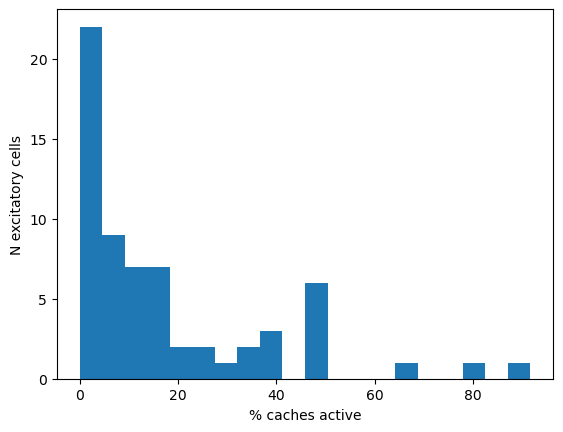

In [39]:
# plot active caches
pct_active = active_cache_frac*100
plt.hist(pct_active, bins=20)
plt.xlabel('% caches active')
plt.ylabel('N excitatory cells')
plt.show()

In [40]:
''' Normalize activity for population analysis '''
# get the baseline rate for each cell (running 30min avg activity)
baseline_window = 30 # minutes
moving_avg_fr = np.zeros_like(inst_firing_rate)
for cell in range(n_cells):
    moving_avg_fr[cell] = helpers.moving_avg(inst_firing_rate[cell], window=baseline_window)

# get the standard deviation (regularize by adding 0.6 Hz)
st_dev_fr = stats.tstd(inst_firing_rate, axis=1) + 0.6
assert st_dev_fr.shape[0] == n_cells

# normalize
norm_fr = inst_firing_rate.copy()
norm_fr -= moving_avg_fr
for cell in range(n_cells):
    norm_fr[cell] /= st_dev_fr[cell]

In [45]:
''' Compute the population activity vectors '''
# collect all the population vectors for this session
visit_vectors_raw = np.zeros((n_visits, n_cells))
for i, (vs, ve) in enumerate(zip(visit_onsets, visit_offsets)):
    visit_vectors_raw[i] = np.mean(norm_fr[:, vs:ve], axis=1)

cache_vectors_raw = np.zeros((n_caches, n_cells))    
for i, (cs, ce) in enumerate(zip(cache_onsets, cache_offsets)):
    cache_vectors_raw[i] = np.mean(norm_fr[:, cs:ce], axis=1)

# compute avg population vectors for all visits, caches
avg_visit_vector = np.mean(visit_vectors_raw, axis=0, keepdims=True)
avg_cache_vector = np.mean(cache_vectors_raw, axis=0, keepdims=True)

# subtract the means across all events
visit_vectors = visit_vectors_raw - avg_visit_vector
cache_vectors = cache_vectors_raw - avg_cache_vector

In [135]:
''' Get the physical and neural distance between each pair of events '''
# visit-visit correlation
visit_corr = 1 - distance.pdist(visit_vectors, 'correlation')
visit_dist = distance.pdist(visit_loc)

# bin by distance
visit_bin_idx = np.digitize(visit_dist, perch_dist_bins)-1
avg_visit_corr = np.zeros(n_bins-1)
sem_visit_corr = np.zeros(n_bins-1)
for b_idx in range(n_bins-1):
    avg_visit_corr[b_idx] = np.mean(visit_corr[visit_bin_idx==b_idx]) 
    sem_visit_corr[b_idx] = stats.sem(visit_corr[visit_bin_idx==b_idx])        
    
# cache-cache correlation
cache_corr = 1 - distance.pdist(cache_vectors, 'correlation')
cache_dist = distance.pdist(cache_loc)

# bin by distance
cache_bin_idx = np.digitize(cache_dist, perch_dist_bins)-1
avg_cache_corr = np.zeros(n_bins-1)
sem_cache_corr = np.zeros(n_bins-1)
for b_idx in range(n_bins-1):
    avg_cache_corr[b_idx] = np.mean(cache_corr[cache_bin_idx==b_idx]) 
    sem_cache_corr[b_idx] = stats.sem(cache_corr[cache_bin_idx==b_idx]) 

In [183]:
all_visit_corr = visit_corr
all_visit_dist = visit_dist
all_cache_corr = cache_corr
all_cache_dist = cache_dist

In [184]:
# average for visits
visit_bin_idx = np.digitize(all_visit_dist, perch_dist_bins)-1
avg_visit_corr = np.zeros(n_bins-1)
for b_idx in range(n_bins-1):
    avg_visit_corr[b_idx] = np.mean(all_visit_corr[visit_bin_idx==b_idx]) 

# normalize by visit-visit correlation at the same site
norm_factor = np.max(avg_visit_corr)
avg_visit_corr_norm = avg_visit_corr / norm_factor

# sem for visits
sem_visit_corr = np.zeros(n_bins-1)
for b_idx in range(n_bins-1):
    sem_visit_corr[b_idx] = stats.sem(all_visit_corr[visit_bin_idx==b_idx] / norm_factor)   

# average and sem for caches
cache_bin_idx = np.digitize(all_cache_dist, perch_dist_bins)-1
avg_cache_corr = np.zeros(n_bins-1)
sem_cache_corr = np.zeros(n_bins-1)
for b_idx in range(n_bins-1):
    avg_cache_corr[b_idx] = np.mean(all_cache_corr[cache_bin_idx==b_idx]) 
    sem_cache_corr[b_idx] = stats.sem(all_cache_corr[cache_bin_idx==b_idx] / norm_factor) 
avg_cache_corr_norm = avg_cache_corr / norm_factor

In [144]:
cache_bin_idx.shape

(276,)

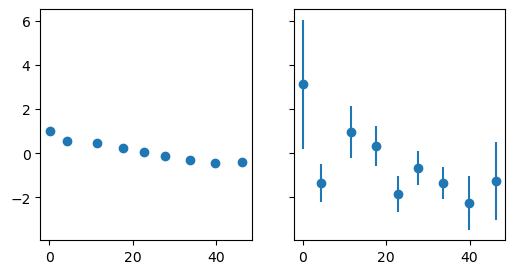

In [188]:
f, ax = plt.subplots(1, 2, figsize=(6, 3), sharey=True)
ax[0].scatter(perch_dist_centers_cm, avg_visit_corr_norm)
ax[0].vlines(perch_dist_centers_cm, 
             avg_visit_corr_norm-sem_visit_corr,
             avg_visit_corr_norm+sem_visit_corr)

ax[1].scatter(perch_dist_centers_cm, avg_cache_corr_norm)
ax[1].vlines(perch_dist_centers_cm, 
             avg_cache_corr_norm-sem_cache_corr,
             avg_cache_corr_norm+sem_cache_corr)
plt.show()

In [145]:
bird_ids = []
data_dict = np.load(data_file, allow_pickle=True).item()
for bird in data_dict.keys():
    bird_ids.append(bird)

In [158]:
# gather the waveform properties and n cells
n_cells_per_bird = np.asarray([])
for i, bird in enumerate(bird_ids):
    if i == 0:
        all_waveform_props = data_dict[bird]['all_waveform_props']
    else:
        waveform_props = data_dict[bird]['all_waveform_props']
        all_waveform_props = np.column_stack([all_waveform_props, waveform_props])
    n_cells_per_bird = np.append(n_cells_per_bird, data_dict[bird]['all_waveform_props'].shape[1])
n_cells_per_bird = n_cells_per_bird.astype(int)
asymm = all_waveform_props[0]
width = all_waveform_props[1]
log_fr = all_waveform_props[2]

In [159]:
bird_idx = bird_ids.index(bird)

In [160]:
n_cells_this_bird = n_cells_per_bird[bird_idx]
start_idx = np.sum(n_cells_per_bird[:bird_idx])
end_idx = start_idx + n_cells_this_bird

In [166]:
exc_idx, inhib_idx = waveform_analysis.clu_waveforms_kmeans(width, asymm, log_fr)

In [189]:
n_cells_this_bird

403